In [1]:
from PipingSystem import PipingSystem
from Elements.Coil import Coil
from Elements.Singularities import SingularityLoss
from Elements.Tube import Tube
import CoolProp.CoolProp as cp
import numpy as np
from Pumps.Lauda import LaudaPumpFit
import matplotlib.pyplot as plt
from scipy.optimize import newton
import Experiments.NaturalConvection as nc

Definimos serpentin

In [2]:
coil = Coil(d_in = 5.15e-3, d_out=6.35e-3, lenght=1, orientation=-90, material="copper", vueltas = 5, pitch=6.35e-3)

In [3]:
np.sqrt((166)**2+((13.6)/(np.pi))**2)*np.pi*14

np.float64(7303.543568691706)

Definimos el sistema

In [4]:
fluxsys = PipingSystem()
fluxsys.add_tube(Tube(d_in = 12.7e-3, d_out = 13.5e-3, lenght=1.5, orientation=0, material="Plastic")) # Primera manguera del lauda
fluxsys.add_singularity_loss(SingularityLoss(0.5)) # Primer cambio de diametro
fluxsys.add_coil(coil) # Serpentin
#fluxsys.add_singularity_loss(SingularityLoss(0.5)) # Segundo cambio de diamtro
#fluxsys.add_tube(Tube(d_in = 12.7e-3, d_out = 13.6e-3, lenght=0.346, orientation=90, material="copper"))
fluxsys.add_singularity_loss(SingularityLoss(0.5)) # Segundo cambio de diamtro
fluxsys.add_tube(Tube(d_in = 12.7e-3, d_out = 13.5e-3, lenght=1.5, orientation=0, material="Plastic")) # Segunda manguera del lauda
fluxsys.conect() # Conectar

Definimos el Fluido

In [5]:
tl = 273.15 + 5
pl = 101325        
mul = 0.002 # Pa*s
rhol = 986.58 # kg/m3
cpl = 4180*1.03 # J /(kg K)
kl = 0.4984 # W/(m K)
prl = mul*cpl/kl
print(prl, kl)

17.276886035313005 0.4984


Buscamos donde cruza la curva del sistema con la curva de la bomba

In [6]:
Q_op, Q_op_lmin, dp_op, dh_op = fluxsys.cross_system_pump(rhol,mul, LaudaPumpFit.Pa4m3s, 3.25e-5,verbose=True);


═════════════════════════════════════════════
        UNTO DE OPERACIÓN DEL SISTEMA        
═════════════════════════════════════════════
 Caudal volumétrico :    2.119 L/min
 Caudal volumétrico      : 3.53e-05 m³/s
 Presión de cruce   :  17814.0 Pa
 Pérdida de altura  :    1.841 m.c.a.
═════════════════════════════════════════════



In [7]:
def ap_from_T(T):
    return (2.5179e-7) * (T**2) + (-1.3127e-4) * T + (1.7210e-2)
def nu_from_T(T):
    return  1.3686547347844438e-06*np.exp(1913.7989961446747/T)

In [8]:
m_dot = Q_op*rhol
# coil = TuClaseSerpentin(...)
# cpl, kl, mul, prl, rhol = ... (Propiedades del fluido interno)

def calcular_salida_y_pared(twater, tin, twall_guess=283.15):
    """
    Simulador predictivo real: Asume que Tin es fijo y DESCONOCE Tout.
    Encuentra Twall y Tout iterando el circuito de resistencias térmicas.
    """
    tol = 0.05
    relax = 0.2
    max_iter = 1000
    
    twall_out = twall_guess # Iteramos sobre la pared exterior
    tout = tin + 1.0        # Valor inicial lógico (sale un poco más caliente de lo que entra)
    q = 0
    
    for i in range(max_iter):
        
        # --- 1) LADO INTERNO (Fluido) ---
        
        # Control de régimen laminar/turbulento
        coil.set_hidraulica(Q_op, rhol, mul)
        hi =coil.get_ht(prl,prl,mul,mul,kl)
        print(hi)
        R_int = 1 / (hi * coil.area_in)
        
        # MÉTODO NTU: Transforma la resistencia interna para garantizar 
        # que el perfil de temperatura no rompa la termodinámica
        NTU = 1 / (R_int * m_dot * cpl)
        epsilon = 1 - np.exp(-NTU)
        R_eff_int = 1 / (epsilon * m_dot * cpl)
        
        # --- 2) PARED (Conducción) ---
        R_cond = np.log(coil.d_out / coil.d_in) / (2 * np.pi * coil.conductivity * coil.lenght)
        
        # --- 3) LADO EXTERNO (Baño y Rayleigh) ---
        tfo = (twater + twall_out) / 2
        if np.isnan(tfo) or tfo < 273.16: tfo = 273.20
            
        beta = ap_from_T(tfo)
        prandtl = cp.PropsSI('Prandtl', 'T', tfo, 'P', 101325, "water")
        nu_o = nu_from_T(tfo) / cp.PropsSI('D', 'T', tfo, 'P', 101325, "water")
        k_bath = cp.PropsSI('L', 'T', tfo, 'P', 101325, "water")
        
        delta_T = abs(twater - twall_out)
        if delta_T < 0.01: delta_T = 0.01
            
        gr = (9.81 * beta * delta_T * (coil.altura**3)) / (nu_o**2)
        Ra = gr * prandtl
        Nuo = 0.0749 * (Ra**0.3421)
        
        # Evitar que ho colapse a cero
        ho = max(Nuo * k_bath / coil.altura, 10.0) 
        R_ext = 1 / (ho * coil.area_out)
        
        # --- 4) BALANCE TÉRMICO GLOBAL ---
        R_tot = R_eff_int + R_cond + R_ext
        
        # El calor real está dictado por el diferencial total: Baño vs Entrada fría
        q_new = (twater - tin) / R_tot
        
        # --- 5) RECALCULAR TEMPERATURAS (Física Pura) ---
        twall_out_new = twater - q_new * R_ext
        tout_new = tin + q_new / (m_dot * cpl)
        
        # --- 6) CONVERGENCIA ---
        # Solo necesitamos que la pared converja, el fluido será consecuencia directa del calor
        if abs(twall_out_new - twall_out) < tol:
            twall_out = twall_out_new
            tout = tout_new
            q = q_new
            break
            
        # Relajación
        twall_out = twall_out + relax * (twall_out_new - twall_out)
        
    return tout, twall_out, q


# --- SIMULACIÓN TRANSITORIA (20 MINUTOS) ---


In [9]:
# --- SIMULACIÓN TRANSITORIA (20 MINUTOS) ---

M_tanque = 0.250 # Masa de agua en el baño (kg)
Cp_tanque = 4180  # J/kgC (Calor específico del agua)
dt = 5          # Paso de tiempo en segundos
tiempo_total = 10*60 # 20 minutos en segundos

# Condiciones iniciales de la simulación
t_bath_actual = 273.15+16 # Temperatura inicial del baño (Ej: 20°C en Kelvin)
tin = 273.15+5         # Temperatura de entrada al serpentín (Ej: 80°C en Kelvin)

# Listas para guardar el historial y graficar después
historial_tiempo = []
historial_t_bath = []
historial_tout = []
historial_q = []
historial_twall = []

print("Iniciando simulación de 20 minutos...")

for t in np.arange(0, tiempo_total, dt):
    # 'tin' se mantiene constante a 273.15 + 8 (o lo que dictes)
    if t == 0:
        tout, twall_out, q = calcular_salida_y_pared(t_bath_actual, tin)
    else:
        tout, twall_out, q = calcular_salida_y_pared(t_bath_actual, tin, twall_guess=twall_out)
    
    # 2. Guardar datos actuales en el historial
    historial_tiempo.append(t / 60.0) # Guardar en minutos
    historial_t_bath.append(t_bath_actual - 273.15) # Guardar en Celsius para fácil lectura
    historial_tout.append(tout - 273.15)
    historial_q.append(q)
    historial_twall.append(twall_out - 273.15)
    
    
    # 3. Calcular el cambio de temperatura del baño
    dT_bath = (-q * dt) / (M_tanque * cp.PropsSI('C', 'T', t_bath_actual, 'P', 101325, "water"))
    
    # 4. Actualizar temperatura para el siguiente segundo
    t_bath_actual += dT_bath

print("Simulación finalizada.")

Iniciando simulación de 20 minutos...
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074773914058
6676.074

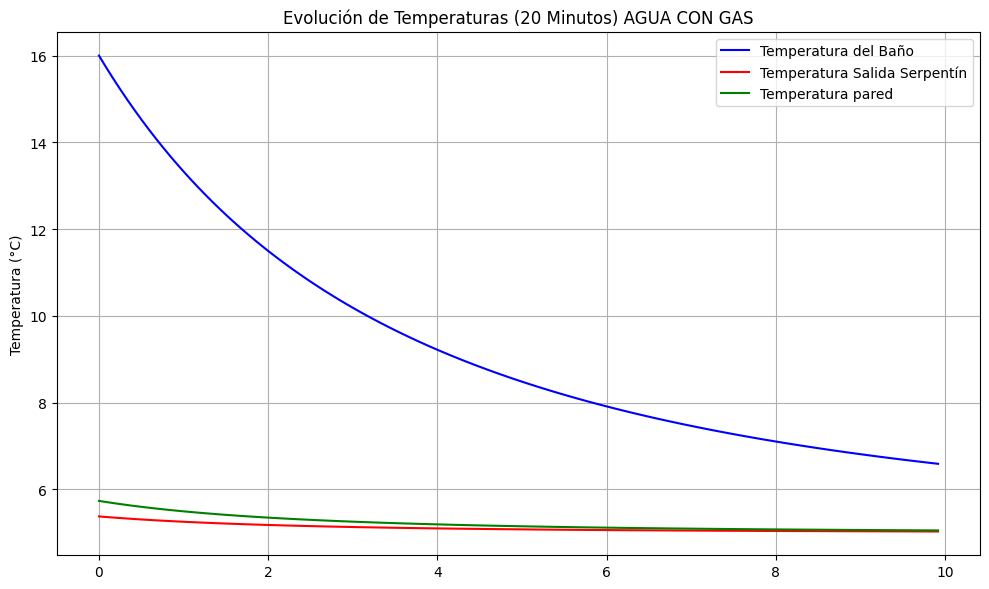

In [10]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 1, 1)
plt.plot(historial_tiempo, historial_t_bath, label="Temperatura del Baño", color='blue')
plt.plot(historial_tiempo, historial_tout, label="Temperatura Salida Serpentín", color='red')
plt.plot(historial_tiempo, historial_twall, label ="Temperatura pared", color = "green")

plt.title("Evolución de Temperaturas (20 Minutos) AGUA CON GAS")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True)

# plt.subplot(2, 1, 2)
# plt.plot(historial_tiempo, historial_q, label="Calor Transferido (q)", color='orange')
# plt.xlabel("Tiempo (Minutos)")
# plt.ylabel("Calor (W)")
# plt.legend()
# plt.grid(True)

plt.tight_layout()
plt.show()